In [322]:
import pandas as pd 
import numpy as np
from scipy import stats 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PowerTransformer

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings

warnings.filterwarnings('ignore')
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#statistical libraries 
from scipy import stats
from scipy.stats import zscore, skew 

# set style for better visualizations 
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("libraries imported successfully!")


libraries imported successfully!


In [323]:
loan_df = pd.read_csv('home_loan_train.csv')

df = loan_df.copy()


In [324]:
df.dropna(subset=['Credit_History'],inplace=True)

In [325]:
df.isnull().sum()

Loan_ID               0
Gender               12
Married               3
Dependents           15
Education             0
Self_Employed        26
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [326]:
numerical =df.select_dtypes(include=['float64','int64']).columns

numerical=numerical.drop('Credit_History')

categorical = df.select_dtypes(include='object').columns
categorical = list(categorical)
categorical.append('Credit_History')

In [327]:
for col in categorical:
 x=df[col].mode()[0]
 df[col]=df[col].fillna(x)

for col in numerical:
  df[col]=df[col].fillna(df[col].median())

In [328]:
df.duplicated().sum()

np.int64(0)

In [329]:
df['Loan_Amount_Term'].skew()

np.float64(-2.3139085450009556)

In [330]:
skewed_vars = ['LoanAmount', 'ApplicantIncome', 'CoapplicantIncome','Loan_Amount_Term']

for var in skewed_vars:
    if var in df.columns:
        if df[var].skew() > 0:
            # Check if variable has zero or negative values
            min_val = df[var].min()
            if min_val <= 0:
                # Use log1p for variables with zeros
                df[f'{var}_log'] = np.log1p(df[var])
                print(f"✓ {var}: Applied log1p transformation (had {min_val:.3f} minimum value)")
            else:
                # Use log for positive values only
                df[f'{var}_log'] = np.log(df[var])
                print(f"✓ {var}: Applied log transformation")
        else:
            pt = PowerTransformer(method='yeo-johnson')
            df[f'{var}_log'] = pt.fit_transform(df[var].values.reshape(-1,1))
    # Check skewness before and after
    original_skew = skew(df[var])
    transformed_skew = skew(df[f'{var}_log'])
    print(f"  Original skewness: {original_skew:.3f} → Transformed skewness: {transformed_skew:.3f}")

print(f"\nDataset shape after log transformation: {df.shape}")
print("New log-transformed columns:", [col for col in df.columns if '_log' in col])


✓ LoanAmount: Applied log transformation
  Original skewness: 2.698 → Transformed skewness: -0.284
✓ ApplicantIncome: Applied log transformation
  Original skewness: 6.490 → Transformed skewness: 0.539
✓ CoapplicantIncome: Applied log1p transformation (had 0.000 minimum value)
  Original skewness: 5.985 → Transformed skewness: -0.153
  Original skewness: -2.308 → Transformed skewness: 0.434

Dataset shape after log transformation: (564, 17)
New log-transformed columns: ['LoanAmount_log', 'ApplicantIncome_log', 'CoapplicantIncome_log', 'Loan_Amount_Term_log']


consider other transformation methods on subsequent evaluations because its over flipping the data i am now having negative skewness 

In [331]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log,ApplicantIncome_log,CoapplicantIncome_log,Loan_Amount_Term_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y,4.844187,8.674026,0.000000,0.17134
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,4.852030,8.430109,7.319202,0.17134
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,4.189655,8.006368,0.000000,0.17134
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4.787492,7.856707,7.765993,0.17134
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,4.948760,8.699515,0.000000,0.17134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,4.262680,7.972466,0.000000,0.17134
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,3.688879,8.320205,0.000000,-2.29551
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,5.533389,8.996157,5.484797,0.17134
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,5.231109,8.933664,0.000000,0.17134


In [332]:
df['Dependents']=df['Dependents'].replace("3+",3)

In [333]:
df['Dependents'].value_counts()

Dependents
0    331
2     95
1     90
3     48
Name: count, dtype: int64

Handling outliers 

In [334]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'LoanAmount_log', 'ApplicantIncome_log', 'CoapplicantIncome_log',
       'Loan_Amount_Term_log'],
      dtype='object')

In [335]:
# univariate analysis of the 
def univariate_numerical_eda(df, column):
    """
    Performs univariate EDA on a single numerical column.
    Displays summary statistics, skewness, kurtosis, histogram, KDE, and boxplot.
    """
    print(f" Feature: {column}")
    print("="*40)
    print(df[column].describe().to_frame())
    print(f"\nSkewness: {df[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    plt.figure(figsize=(12,4))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True, bins=30, color='teal')
    plt.title(f'\n Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[column], color='teal')
    plt.title(f'\n Boxplot of {column}', fontsize=13)

    plt.tight_layout()
    plt.show()

    # Optional note on transformation
    if abs(df[column].skew()) > 1:
        print(f"\n {column} is highly skewed. Consider log or Box-Cox transformation.")
    elif abs(df[column].skew()) > 0.5:
        print(f"{column} is moderately skewed.")
    else:
        print(f"{column} is fairly symmetric.")


['LoanAmount_log', 'ApplicantIncome_log', 'CoapplicantIncome_log', 'Loan_Amount_Term_log']
 Feature: LoanAmount_log
       LoanAmount_log
count      564.000000
mean         4.850123
std          0.495004
min          2.197225
25%          4.622510
50%          4.844187
75%          5.087596
max          6.551080

Skewness: -0.285
Kurtosis: 2.953


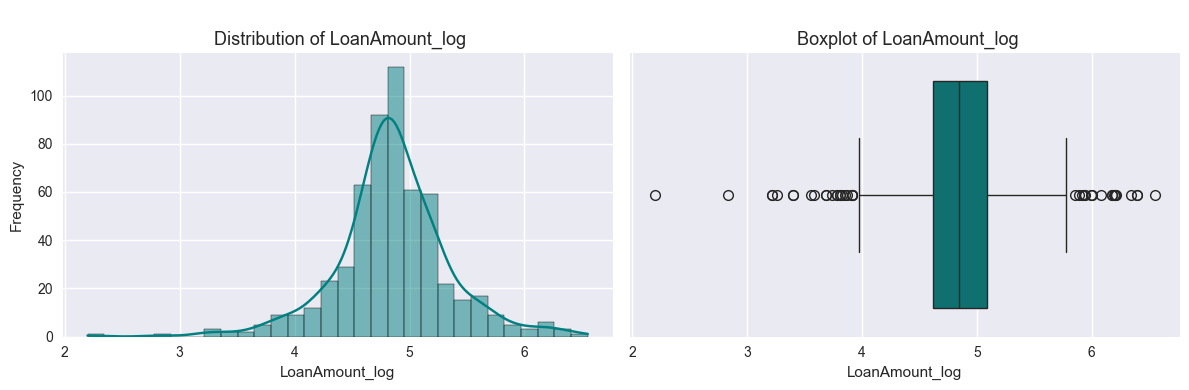

LoanAmount_log is fairly symmetric.
 Feature: ApplicantIncome_log
       ApplicantIncome_log
count           564.000000
mean              8.349914
std               0.644991
min               5.010635
25%               7.969963
50%               8.246696
75%               8.666259
max              11.302204

Skewness: 0.540
Kurtosis: 3.763


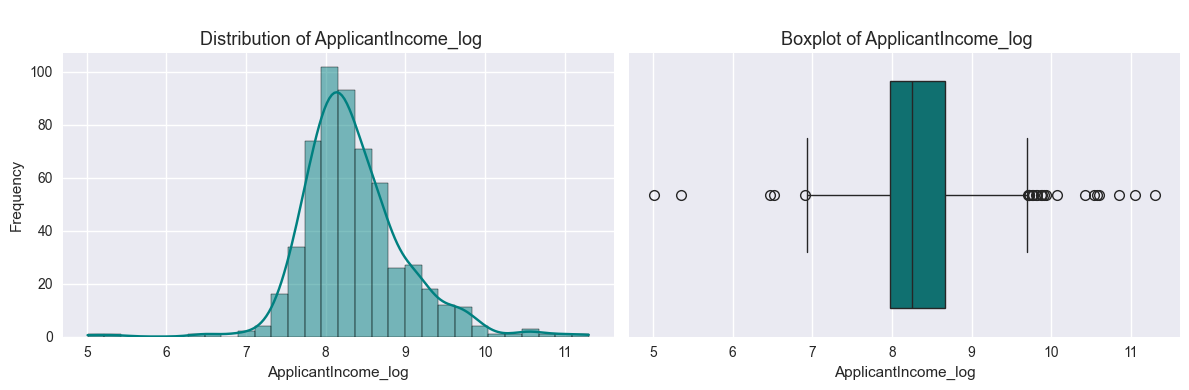

ApplicantIncome_log is moderately skewed.
 Feature: CoapplicantIncome_log
       CoapplicantIncome_log
count             564.000000
mean                4.234564
std                 3.868947
min                 0.000000
25%                 0.000000
50%                 7.008802
75%                 7.719130
max                10.429340

Skewness: -0.153
Kurtosis: -1.924


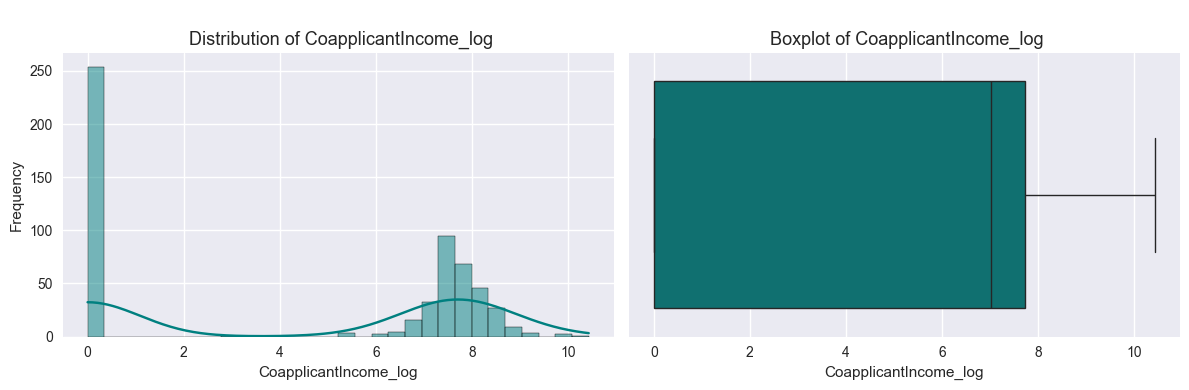

CoapplicantIncome_log is fairly symmetric.
 Feature: Loan_Amount_Term_log
       Loan_Amount_Term_log
count          5.640000e+02
mean          -3.763735e-16
std            1.000888e+00
min           -2.635093e+00
25%            1.713398e-01
50%            1.713398e-01
75%            1.713398e-01
max            4.101208e+00

Skewness: 0.435
Kurtosis: 7.096


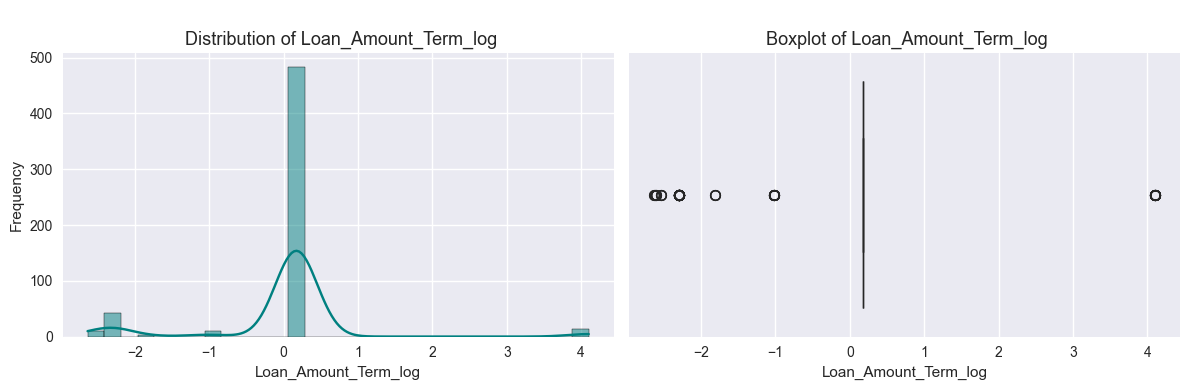

Loan_Amount_Term_log is fairly symmetric.


In [336]:
numer= [column for column in df.columns if  any( keyword in column.lower() for keyword in ['log'])]
print(numer)
for column in numer:
    univariate_numerical_eda(df,column)

we still have outliers so i move forward if handling them using Robust scaler

In [337]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log,ApplicantIncome_log,CoapplicantIncome_log,Loan_Amount_Term_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y,4.844187,8.674026,0.000000,0.17134
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,4.852030,8.430109,7.319202,0.17134
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,4.189655,8.006368,0.000000,0.17134
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4.787492,7.856707,7.765993,0.17134
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,4.948760,8.699515,0.000000,0.17134


In [338]:
scaler = StandardScaler()
df[numer]= scaler.fit_transform(df[numer])

In [339]:
# for column in numer:
#     univariate_numerical_eda(df,column)

In [340]:


df['Loan_to_Income_Ratio'] = (df['LoanAmount_log']) / (df['ApplicantIncome_log'] + df['CoapplicantIncome_log'])


In [341]:
df['Total_Income']= df['ApplicantIncome']  +	df['CoapplicantIncome']

# Feature 1: People per Dollar (Inverse of Income per person)
# Lower value indicates more people sharing the income
df['amountspent_Per_Person'] = df['Total_Income'] / (df['Dependents'].astype(int) + 1) # Add 1 for the applicant

# Combine married status and dependents count into a single indicator
df['Household_Load'] = df['Dependents'].astype(int) + df['Married'].map({'No': 1, 'Yes': 2})



ashawa consult

Ecncoding 

In [ ]:
df=df.drop('Loan_ID',axis=1)
le = LabelEncoder()
df["gender_encoded"] = le.fit_transform(df["Gender"])

#Step 2: Intialize ordinal encoder
oe = OrdinalEncoder(categories=edu_order)

#Step 3: Fit and transform
df["education_encoded"] = oe.fit_transform(df[["Education Level"]])

label = OneHotEncoder(sparse_output=False, drop="first")
for cat in categorical:
    if cat in df.columns:
        df[cat]=label.fit_transform(df[[cat]])


TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']